In [14]:
import pandas as pd
import numpy as np
from preprocessing import filter_tags
from recommender import taste_vector

In [2]:
tags = filter_tags()
taste = taste_vector()
tagtotaste = {"Tags" : tags, "Taste": taste}
dataframe = pd.DataFrame(tagtotaste)
dataframe.head(10)
sortedframe = dataframe.sort_values(by = "Taste", ascending = False)
sortedframe.head(10)

    
    

,Tags,Taste
0,singleplayer,55
4,story rich,36
1,atmospheric,33
18,third person,33
3,rpg,30
2,great soundtrack,27
21,multiplayer,26
5,open world,21
6,first person,20
9,exploration,19


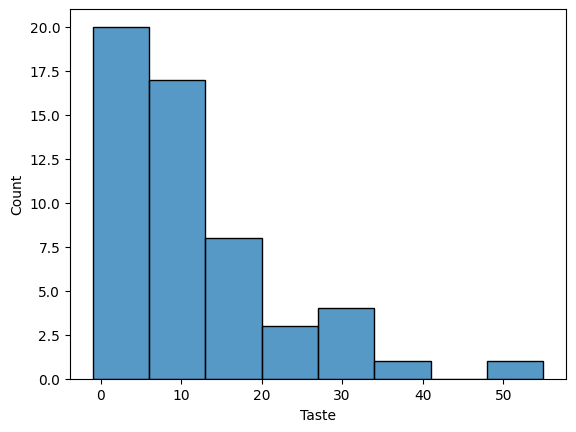

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data=sortedframe, x="Taste")
plt.show()

In [4]:
from preprocessing import preprocess_data
tag_counts, _= preprocess_data()
sortedframe["Frequency"] = sortedframe["Tags"].map(tag_counts)
sortedframe.head(10)

,Tags,Taste,Frequency
0,singleplayer,55,53
4,story rich,36,28
1,atmospheric,33,18
18,third person,33,33
3,rpg,30,20
2,great soundtrack,27,9
21,multiplayer,26,31
5,open world,21,26
6,first person,20,15
9,exploration,19,12


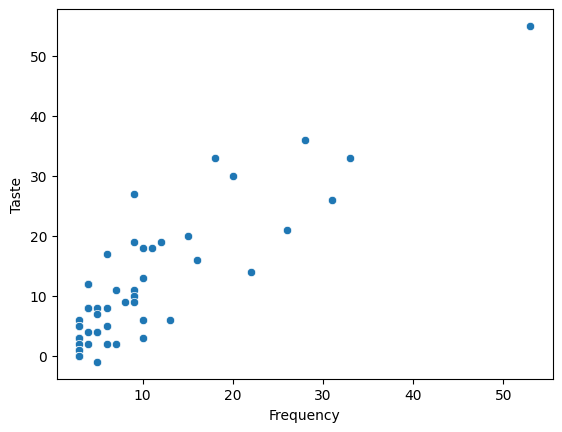

In [5]:
sns.scatterplot(
    data = sortedframe,
    x = sortedframe["Frequency"],
    y = sortedframe["Taste"],
)
plt.show()

In [6]:
sortedframe["Frequency"].corr(sortedframe["Taste"])

np.float64(0.8671286204106103)

In [7]:

sortedframe["Average Score"] = sortedframe["Taste"]/sortedframe["Frequency"]
sortedframe.head(10)

,Tags,Taste,Frequency,Average Score
0,singleplayer,55,53,1.037736
4,story rich,36,28,1.285714
1,atmospheric,33,18,1.833333
18,third person,33,33,1.000000
3,rpg,30,20,1.500000
2,great soundtrack,27,9,3.000000
21,multiplayer,26,31,0.838710
5,open world,21,26,0.807692
6,first person,20,15,1.333333
9,exploration,19,12,1.583333


In [8]:
sortedbyavg = sortedframe.sort_values(
    by = "Average Score", ascending = False)
sortedbyavg.head(10)

,Tags,Taste,Frequency,Average Score
2,great soundtrack,27,9,3.000000
31,difficult,12,4,3.000000
32,souls like,12,4,3.000000
29,dark fantasy,12,4,3.000000
11,violent,17,6,2.833333
13,action rpg,19,9,2.111111
30,multiple endings,6,3,2.000000
14,mature,8,4,2.000000
41,hack and slash,8,4,2.000000
38,party based rpg,8,4,2.000000


In [32]:
from recommender import game_weights
p = game_weights()
q = np.mean(p)
g = 0

In [33]:
m = 5
smoothed_array = []
for i in range (len(sortedframe)):
        smoothed_score = ((sortedframe["Frequency"].iloc[i]*sortedframe["Average Score"].iloc[i]) + (m*g))/(sortedframe["Frequency"].iloc[i] + m)
        smoothed_array.append(smoothed_score)
sortedframe["Smoothed Score"] = smoothed_array
sortedbysmooth = sortedframe.sort_values(
    by = "Smoothed Score", ascending = False)
sortedbysmooth.tail(10)

,Tags,Taste,Frequency,Average Score,Smoothed Score
42,competitive,2,4,0.500000,0.222222
17,crime,3,10,0.300000,0.200000
33,free to play,2,6,0.333333,0.181818
40,parkour,2,7,0.285714,0.166667
53,superhero,1,3,0.333333,0.125000
43,team based,1,3,0.333333,0.125000
48,bullet time,0,3,0.000000,0.000000
44,strategy,0,3,0.000000,0.000000
50,war,0,3,0.000000,0.000000
35,story,-1,5,-0.200000,-0.100000


In [34]:
sortedbysmooth.head(10)

,Tags,Taste,Frequency,Average Score,Smoothed Score
2,great soundtrack,27,9,3.000000,1.928571
11,violent,17,6,2.833333,1.545455
1,atmospheric,33,18,1.833333,1.434783
13,action rpg,19,9,2.111111,1.357143
29,dark fantasy,12,4,3.000000,1.333333
31,difficult,12,4,3.000000,1.333333
32,souls like,12,4,3.000000,1.333333
27,fantasy,18,10,1.800000,1.200000
3,rpg,30,20,1.500000,1.200000
8,first person shooter,18,11,1.636364,1.125000


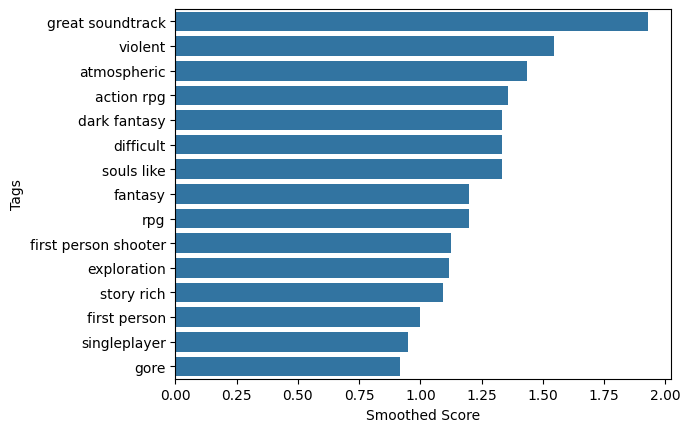

In [35]:
sns.barplot(
    data = sortedbysmooth.head(15),
    x = "Smoothed Score",
    y = "Tags" )
plt.show()